<div style="background: linear-gradient(135deg, #1B2A4A 0%, #0D7C66 100%); padding: 40px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: white; font-family: Georgia, serif; margin: 0; font-size: 2.4em;">
🔍 Notebook 2: Data Deep Dive
</h1>
<p style="color: #C9932F; font-size: 1.3em; margin-top: 10px; font-family: Calibri, sans-serif;">
Brazilian E-Commerce (Olist) — Bivariate Analysis & Feature–Target Relationships
</p>
<p style="color: #B0D0D0; font-size: 0.95em; margin-top: 8px;">
E-Commerce Analytics · MBA Advanced Analytics · 2025–26
</p>
</div>

<div style="background: #FFFFFF; border: 2px solid #0D7C66; padding: 20px 28px; border-radius: 10px; margin: 10px 0 20px 0;">
<h3 style="color: #1B2A4A; margin-top: 0;">Notebook Roadmap</h3>
<ol style="color: #333; font-size: 1.05em; line-height: 1.9;">
<li><strong>Setup and Load Master Table</strong></li>
<li><strong>Delivery Delay vs Bad Experience</strong> — The primary driver</li>
<li><strong>Categorical Features vs Target</strong> — Payment type, category, state</li>
<li><strong>Numeric Features vs Target</strong> — KDE and box plots</li>
<li><strong>Outlier Detection</strong> — Price, freight, delivery extremes</li>
<li><strong>Cross-Feature Interactions</strong> — Combined feature effects</li>
<li><strong>Temporal Patterns</strong> — Hour, day, month effects</li>
<li><strong>Correlation Heatmap</strong> — Full numeric correlation landscape</li>
<li><strong>Feature Scorecard</strong> — Rank all features by association with target</li>
</ol>
</div>

> **Input:** olist_master.csv built in Session 1  
> **Target:** bad_experience (review_score <= 2 = 1, else 0)


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 1: Setup and Load Master Table</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
from scipy import stats
from scipy.stats import pointbiserialr, chi2_contingency

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 120,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'axes.titleweight': 'bold', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
})

NAVY   = '#1B2A4A'
TEAL   = '#0D7C66'
GOLD   = '#C9932F'
CORAL  = '#D95F4B'
PURPLE = '#6B5EA8'
BLUE   = '#3A8FB5'
PALETTE = [NAVY, TEAL, GOLD, CORAL, PURPLE, BLUE]
sns.set_palette(PALETTE)
print("Libraries loaded.")


Libraries loaded.


In [2]:
DATA_DIR = r'C:\Users\DevA\OneDrive\Desktop\All in one - Desktop Files\MBA\Q8\AI ML\Dataset 3'

master = pd.read_csv(os.path.join(DATA_DIR, 'olist_master.csv'), parse_dates=[
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

# Rebuild delay_bucket and order_value_bin if not saved
bins   = [-999, -5, 0, 3, 7, 14, 999]
labels = ['Very Early (>5d)', 'Early (1-5d)', 'On Time',
          'Slightly Late (1-3d)', 'Late (4-7d)', 'Very Late (8d+)']
master['delay_bucket'] = pd.cut(master['delivery_delay_days'], bins=bins, labels=labels)

master['order_value_bin'] = pd.qcut(
    master['total_order_value'],
    q=4, labels=['Low', 'Mid-Low', 'Mid-High', 'High'], duplicates='drop')

print(f"Master table: {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"Bad experience rate: {master['bad_experience'].mean():.2%}")
print(f"Columns: {list(master.columns)}")


Master table: 96,478 rows x 36 columns
Bad experience rate: 12.72%
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_city', 'customer_state', 'n_items', 'total_price', 'total_freight', 'avg_price', 'n_unique_sellers', 'n_unique_products', 'total_payment', 'n_payment_methods', 'max_installments', 'payment_type', 'review_score', 'main_category', 'avg_weight_g', 'bad_experience', 'delivery_delay_days', 'actual_delivery_days', 'approval_time_hours', 'is_late', 'freight_ratio', 'total_order_value', 'avg_item_value', 'purchase_hour', 'purchase_dayofweek', 'purchase_month', 'delay_bucket', 'order_value_bin']


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 2: Delivery Delay vs Bad Experience</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">The most important relationship in this dataset</p>
</div>

In [3]:
late_bad   = master[master['is_late'] == 1]['bad_experience'].mean()
ontime_bad = master[master['is_late'] == 0]['bad_experience'].mean()

print(f"Bad experience rate - LATE orders    : {late_bad:.2%}")
print(f"Bad experience rate - ON-TIME orders : {ontime_bad:.2%}")
if ontime_bad > 0:
    print(f"Late orders are {late_bad/ontime_bad:.1f}x more likely to generate a bad review")

bucket_stats = (master.groupby('delay_bucket', observed=True)['bad_experience']
                .agg(bad_rate='mean', count='count').reset_index())
bucket_stats['bad_rate_pct'] = bucket_stats['bad_rate'] * 100

print("\nBad Experience Rate by Delivery Delay Bucket:")
print(bucket_stats.to_string(index=False))


Bad experience rate - LATE orders    : 53.29%
Bad experience rate - ON-TIME orders : 9.17%
Late orders are 5.8x more likely to generate a bad review

Bad Experience Rate by Delivery Delay Bucket:
        delay_bucket  bad_rate  count  bad_rate_pct
    Very Early (>5d)    0.0897  79900        8.9737
        Early (1-5d)    0.1095   8805       10.9483
             On Time    0.1948   2618       19.4805
Slightly Late (1-3d)    0.6010   1832       60.0983
         Late (4-7d)    0.7630   1764       76.3039
     Very Late (8d+)    0.7614   1551       76.1444


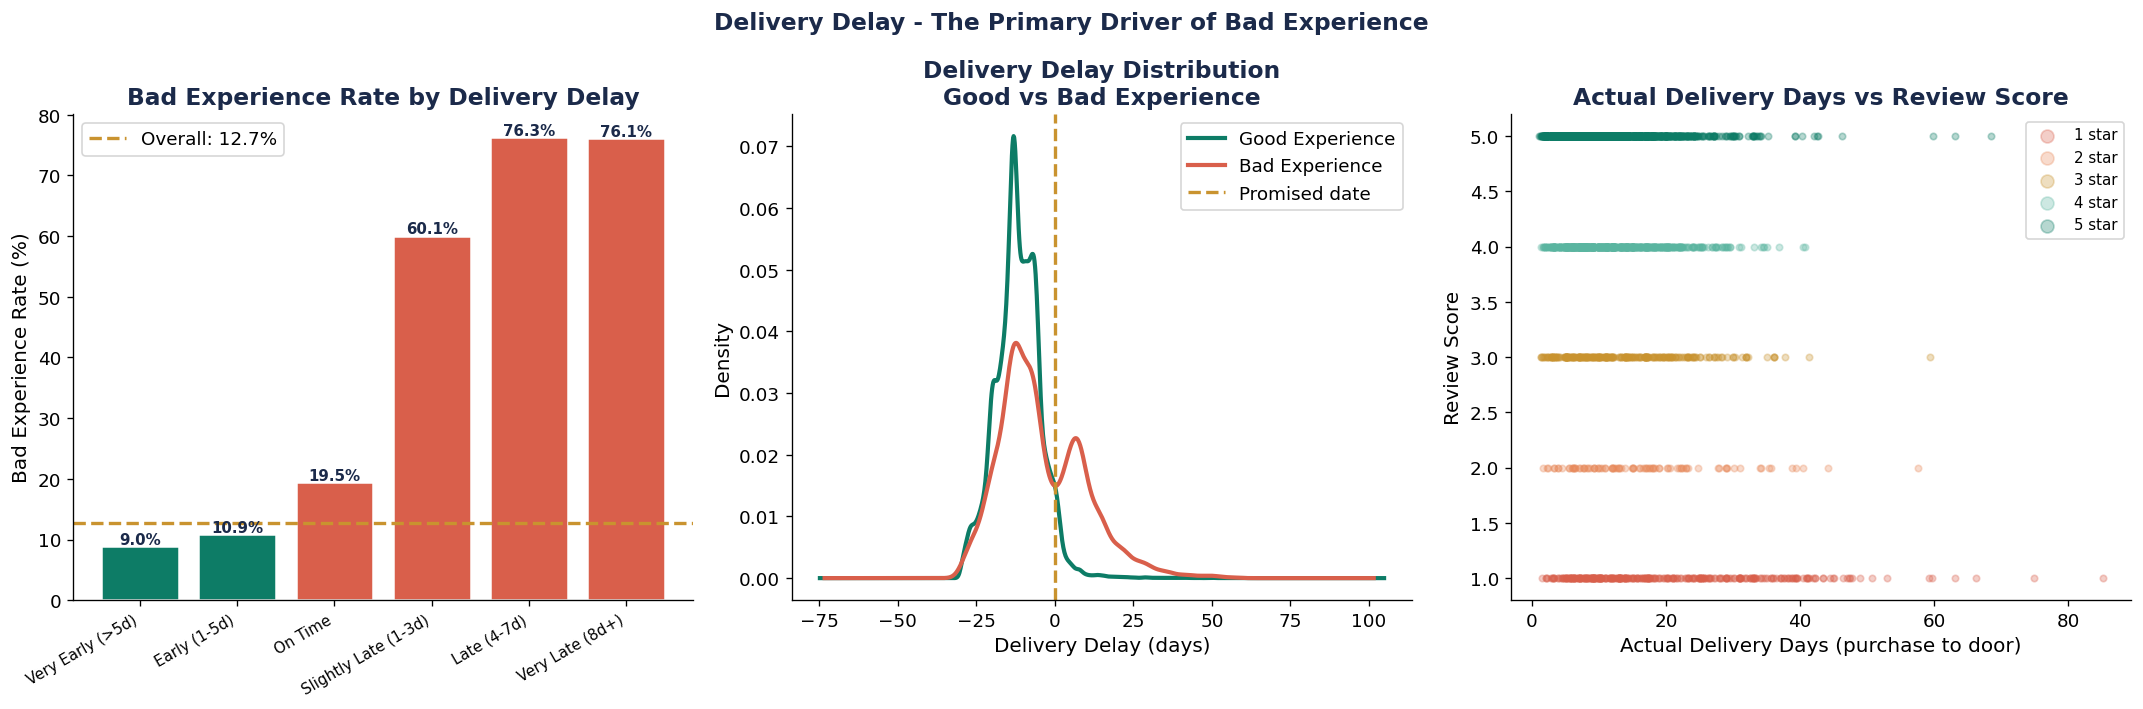

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Bad rate by delay bucket
ax = axes[0]
overall_rate = master['bad_experience'].mean() * 100
colors = [CORAL if r > overall_rate else TEAL for r in bucket_stats['bad_rate_pct']]
bars = ax.bar(range(len(bucket_stats)), bucket_stats['bad_rate_pct'],
              color=colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(bucket_stats)))
ax.set_xticklabels(bucket_stats['delay_bucket'], rotation=30, ha='right', fontsize=9)
ax.set_title('Bad Experience Rate by Delivery Delay', color=NAVY, fontweight='bold')
ax.set_ylabel('Bad Experience Rate (%)')
ax.axhline(overall_rate, color=GOLD, linewidth=2, linestyle='--',
           label=f'Overall: {overall_rate:.1f}%')
ax.legend()
for bar, val in zip(bars, bucket_stats['bad_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold', color=NAVY)

# Plot 2: KDE delay — good vs bad
ax = axes[1]
good = master[master['bad_experience'] == 0]['delivery_delay_days'].dropna()
bad  = master[master['bad_experience'] == 1]['delivery_delay_days'].dropna()
good = good[(good > -30) & (good < 60)]
bad  = bad[(bad > -30) & (bad < 60)]
if len(good) > 10:
    good.plot(kind='kde', ax=ax, color=TEAL, linewidth=2.5, label='Good Experience')
if len(bad) > 10:
    bad.plot(kind='kde', ax=ax, color=CORAL, linewidth=2.5, label='Bad Experience')
ax.axvline(0, color=GOLD, linewidth=2, linestyle='--', label='Promised date')
ax.set_title('Delivery Delay Distribution\nGood vs Bad Experience', color=NAVY, fontweight='bold')
ax.set_xlabel('Delivery Delay (days)')
ax.legend()

# Plot 3: Actual delivery days vs review score scatter
ax = axes[2]
sample = master.dropna(subset=['actual_delivery_days', 'review_score']).sample(
    min(3000, master.dropna(subset=['actual_delivery_days', 'review_score']).shape[0]),
    random_state=42)
score_colors = {1: CORAL, 2: '#E8895A', 3: GOLD, 4: '#5AB5A0', 5: TEAL}
for score in sorted(sample['review_score'].unique()):
    sub = sample[sample['review_score'] == score]
    c = score_colors.get(int(score), BLUE)
    ax.scatter(sub['actual_delivery_days'], sub['review_score'],
               alpha=0.3, s=15, color=c, label=f'{int(score)} star')
ax.set_title('Actual Delivery Days vs Review Score', color=NAVY, fontweight='bold')
ax.set_xlabel('Actual Delivery Days (purchase to door)')
ax.set_ylabel('Review Score')
ax.legend(markerscale=2, fontsize=9)

plt.suptitle('Delivery Delay - The Primary Driver of Bad Experience',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 3: Categorical Features vs Target</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Payment type, product category, customer state</p>
</div>

In [5]:
overall = master['bad_experience'].mean() * 100

pay_stats = (master.groupby('payment_type')['bad_experience']
             .agg(bad_rate='mean', count='count').reset_index()
             .sort_values('bad_rate', ascending=False))
pay_stats['bad_rate_pct'] = pay_stats['bad_rate'] * 100

top_states = master['customer_state'].value_counts().head(10).index
state_stats = (master[master['customer_state'].isin(top_states)]
               .groupby('customer_state')['bad_experience']
               .agg(bad_rate='mean', count='count').reset_index()
               .sort_values('bad_rate', ascending=False))
state_stats['bad_rate_pct'] = state_stats['bad_rate'] * 100

top_cats = master['main_category'].value_counts().head(12).index
cat_stats = (master[master['main_category'].isin(top_cats)]
             .groupby('main_category')['bad_experience']
             .agg(bad_rate='mean', count='count').reset_index()
             .sort_values('bad_rate', ascending=False))
cat_stats['bad_rate_pct'] = cat_stats['bad_rate'] * 100

print("Bad Experience Rate by Payment Type:")
print(pay_stats[['payment_type','bad_rate_pct','count']].to_string(index=False))


Bad Experience Rate by Payment Type:
payment_type  bad_rate_pct  count
     voucher       14.4546   1861
 credit_card       12.7845  73941
      boleto       12.4329  19191
  debit_card       11.0512   1484


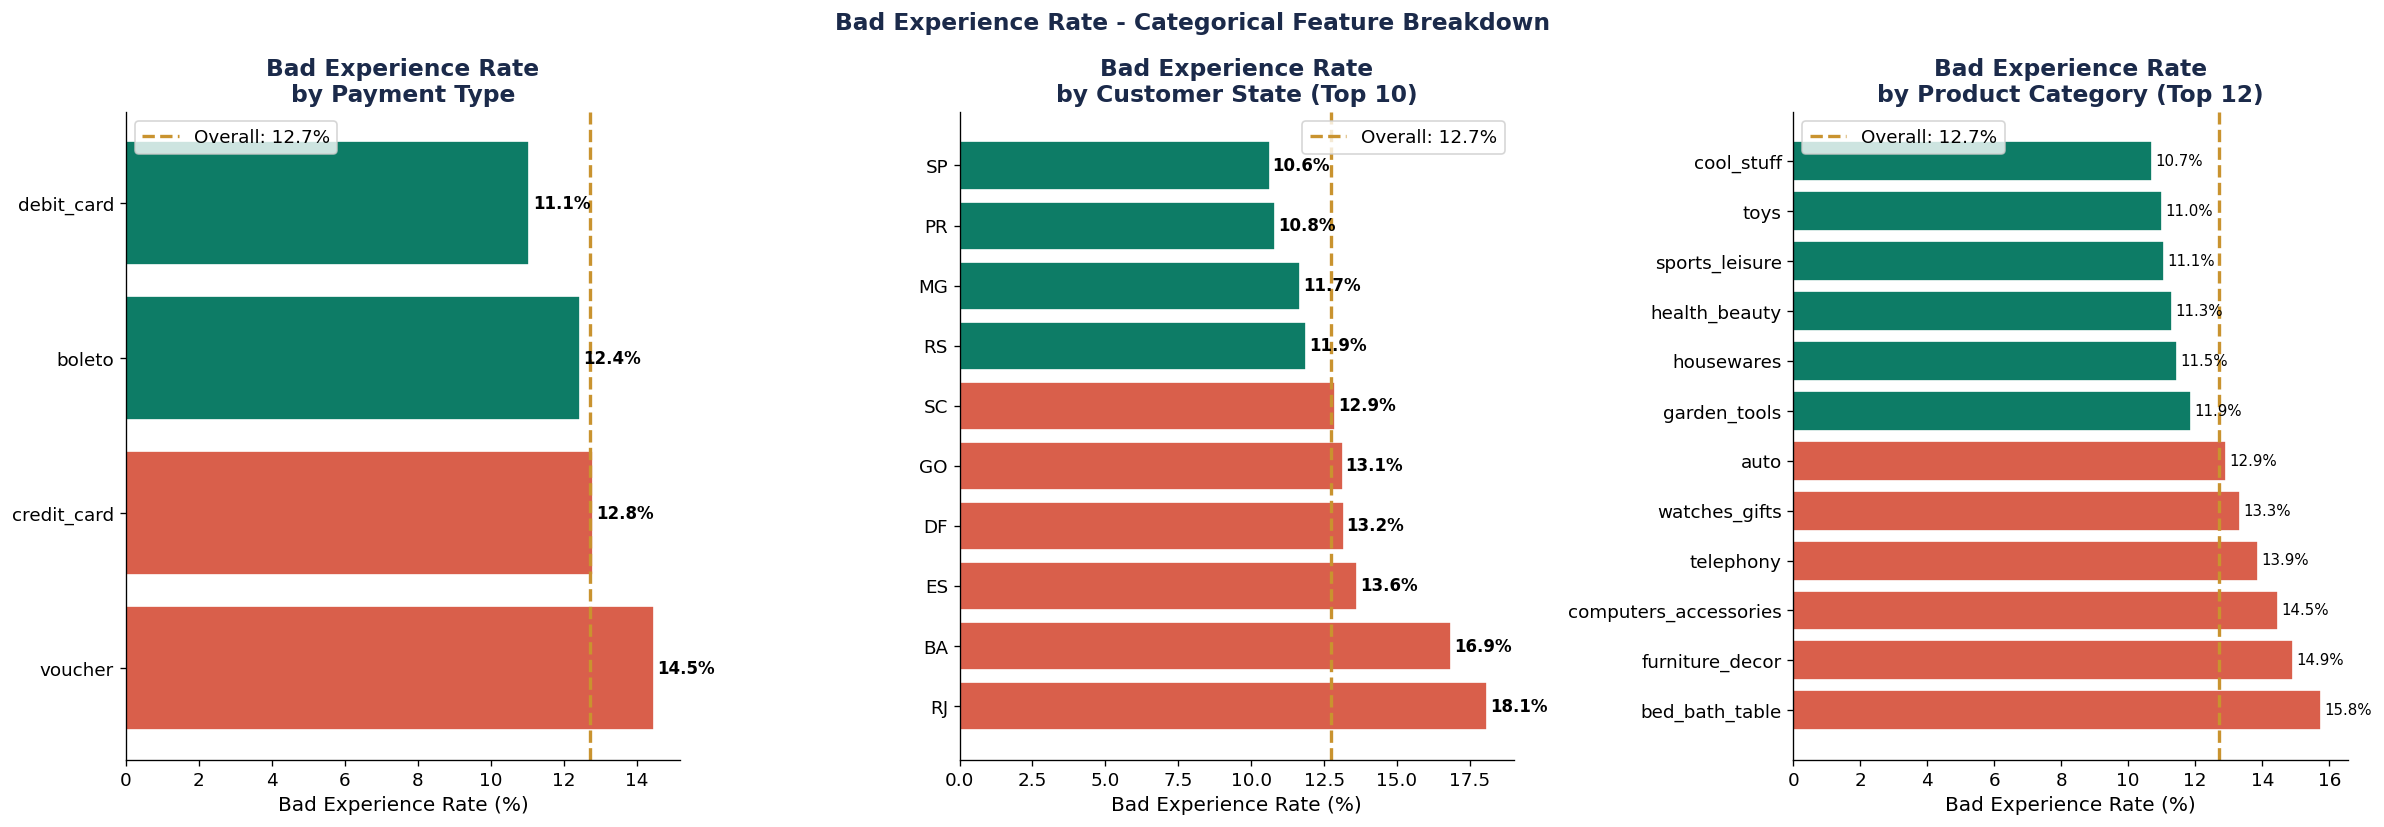

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Plot 1: Payment type
ax = axes[0]
colors = [CORAL if r > overall else TEAL for r in pay_stats['bad_rate_pct']]
bars = ax.barh(pay_stats['payment_type'], pay_stats['bad_rate_pct'],
               color=colors, edgecolor='white')
ax.axvline(overall, color=GOLD, linewidth=2, linestyle='--', label=f'Overall: {overall:.1f}%')
ax.set_title('Bad Experience Rate\nby Payment Type', color=NAVY, fontweight='bold')
ax.set_xlabel('Bad Experience Rate (%)')
for bar, val in zip(bars, pay_stats['bad_rate_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.legend()

# Plot 2: State
ax = axes[1]
colors = [CORAL if r > overall else TEAL for r in state_stats['bad_rate_pct']]
bars = ax.barh(state_stats['customer_state'], state_stats['bad_rate_pct'],
               color=colors, edgecolor='white')
ax.axvline(overall, color=GOLD, linewidth=2, linestyle='--', label=f'Overall: {overall:.1f}%')
ax.set_title('Bad Experience Rate\nby Customer State (Top 10)', color=NAVY, fontweight='bold')
ax.set_xlabel('Bad Experience Rate (%)')
for bar, val in zip(bars, state_stats['bad_rate_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.legend()

# Plot 3: Category
ax = axes[2]
colors = [CORAL if r > overall else TEAL for r in cat_stats['bad_rate_pct']]
bars = ax.barh(cat_stats['main_category'], cat_stats['bad_rate_pct'],
               color=colors, edgecolor='white')
ax.axvline(overall, color=GOLD, linewidth=2, linestyle='--', label=f'Overall: {overall:.1f}%')
ax.set_title('Bad Experience Rate\nby Product Category (Top 12)', color=NAVY, fontweight='bold')
ax.set_xlabel('Bad Experience Rate (%)')
for bar, val in zip(bars, cat_stats['bad_rate_pct']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.legend()

plt.suptitle('Bad Experience Rate - Categorical Feature Breakdown',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 4: Numeric Features vs Target</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">KDE overlays and box plots split by good vs bad experience</p>
</div>

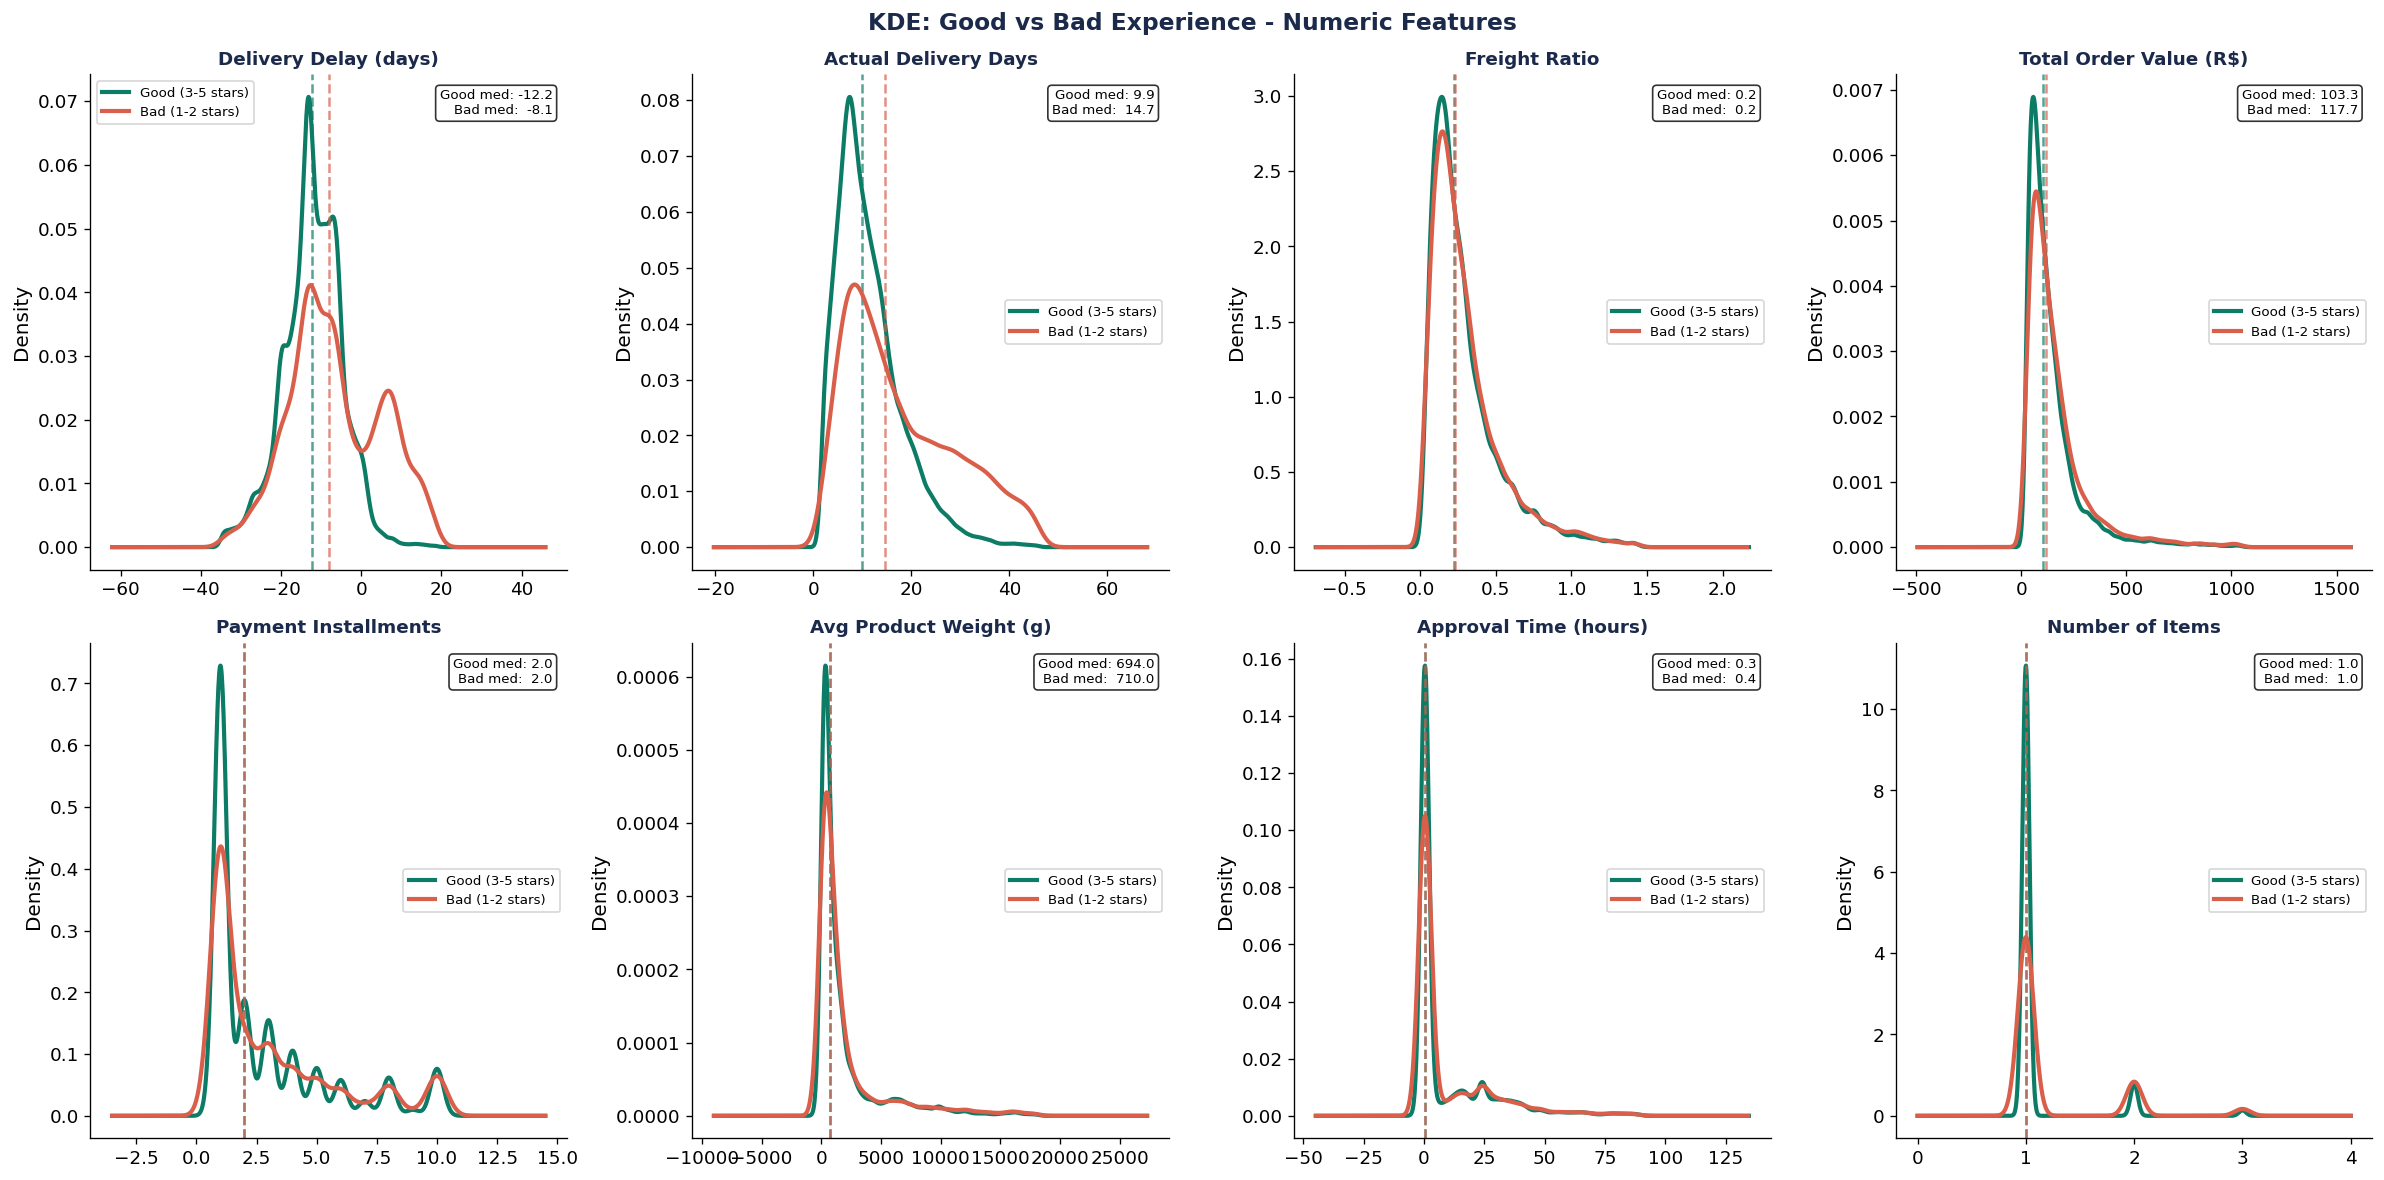

In [7]:
numeric_features = [
    ('delivery_delay_days', 'Delivery Delay (days)'),
    ('actual_delivery_days', 'Actual Delivery Days'),
    ('freight_ratio', 'Freight Ratio'),
    ('total_order_value', 'Total Order Value (R$)'),
    ('max_installments', 'Payment Installments'),
    ('avg_weight_g', 'Avg Product Weight (g)'),
    ('approval_time_hours', 'Approval Time (hours)'),
    ('n_items', 'Number of Items'),
]

# Filter to features present in master
numeric_features = [(c, l) for c, l in numeric_features if c in master.columns]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, (col, label) in enumerate(numeric_features):
    ax = axes[i]
    all_vals = master[col].dropna()
    lo = all_vals.quantile(0.01)
    hi = all_vals.quantile(0.99)

    good = master[master['bad_experience'] == 0][col].dropna()
    bad  = master[master['bad_experience'] == 1][col].dropna()
    good = good[(good >= lo) & (good <= hi)]
    bad  = bad[(bad >= lo) & (bad <= hi)]

    if len(good) > 10:
        good.plot(kind='kde', ax=ax, color=TEAL, linewidth=2.5, label='Good (3-5 stars)')
        ax.axvline(good.median(), color=TEAL, linewidth=1.5, linestyle='--', alpha=0.7)
    if len(bad) > 10:
        bad.plot(kind='kde', ax=ax, color=CORAL, linewidth=2.5, label='Bad (1-2 stars)')
        ax.axvline(bad.median(), color=CORAL, linewidth=1.5, linestyle='--', alpha=0.7)

    ax.set_title(label, color=NAVY, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

    if len(good) > 0 and len(bad) > 0:
        ax.text(0.97, 0.97,
                f'Good med: {good.median():.1f}\nBad med:  {bad.median():.1f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide unused axes
for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('KDE: Good vs Bad Experience - Numeric Features',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


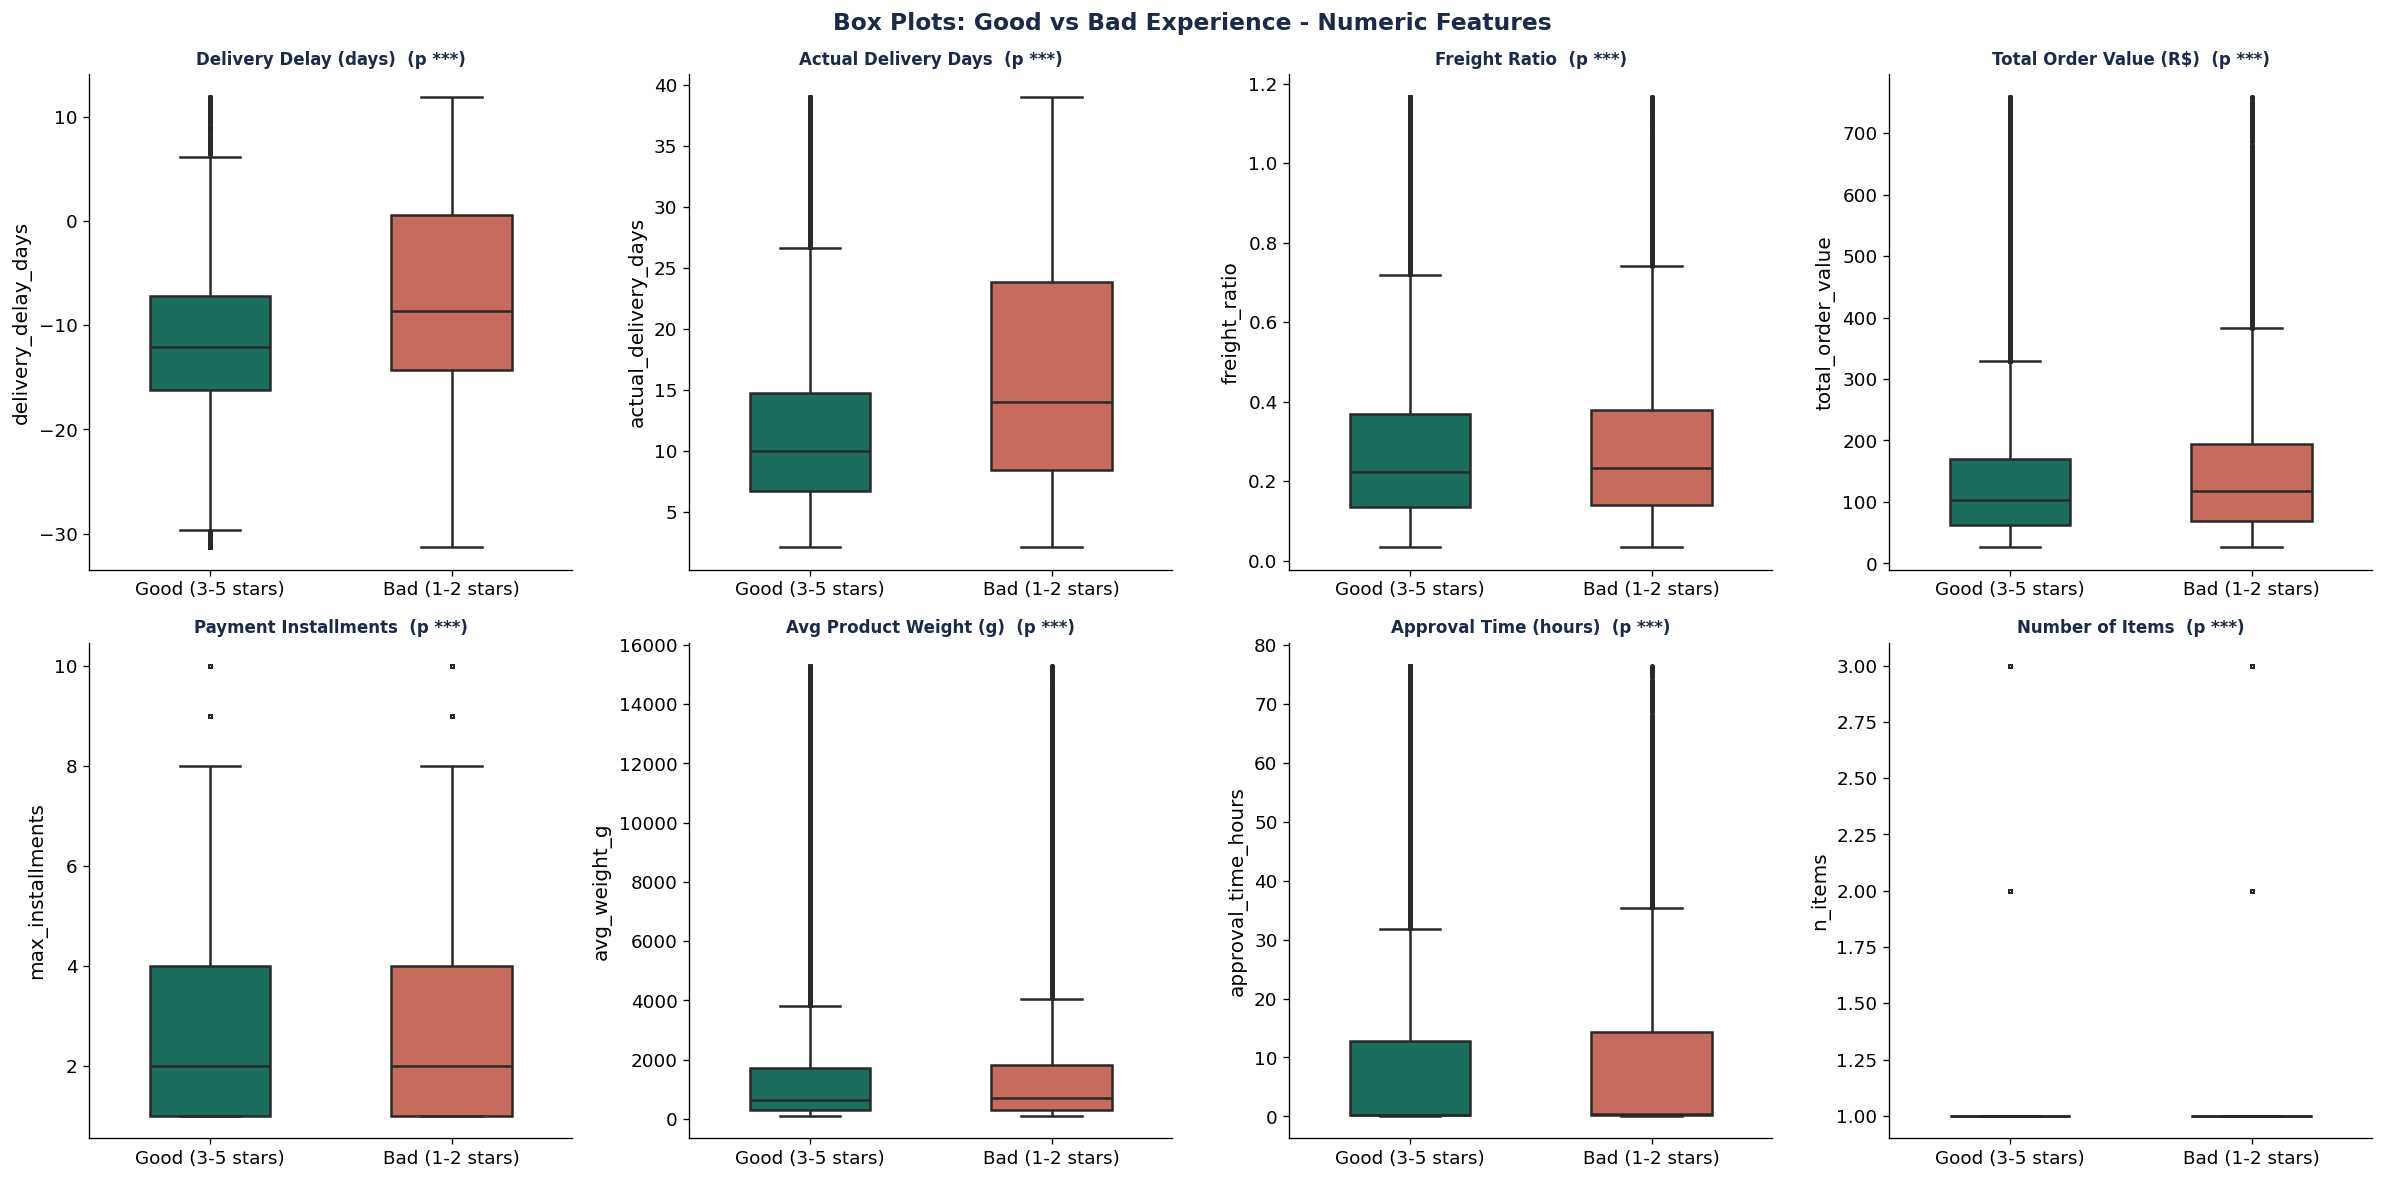

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, (col, label) in enumerate(numeric_features):
    ax = axes[i]
    plot_data = master[[col, 'bad_experience']].dropna().copy()
    lo = plot_data[col].quantile(0.02)
    hi = plot_data[col].quantile(0.98)
    plot_data = plot_data[(plot_data[col] >= lo) & (plot_data[col] <= hi)].copy()
    plot_data['Experience'] = plot_data['bad_experience'].map(
        {0: 'Good (3-5 stars)', 1: 'Bad (1-2 stars)'})

    sns.boxplot(data=plot_data, x='Experience', y=col, ax=ax,
                palette={'Good (3-5 stars)': TEAL, 'Bad (1-2 stars)': CORAL},
                width=0.5, linewidth=1.5, fliersize=2)

    g = master[master['bad_experience'] == 0][col].dropna()
    b = master[master['bad_experience'] == 1][col].dropna()
    title = label
    if len(g) > 10 and len(b) > 10:
        _, p = stats.mannwhitneyu(g, b, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        title = f'{label}  (p {sig})'
    ax.set_title(title, color=NAVY, fontweight='bold', fontsize=10)
    ax.set_xlabel('')

for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots: Good vs Bad Experience - Numeric Features',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 5: Outlier Detection</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Identifying extreme values that could skew analysis</p>
</div>

In [9]:
outlier_cols = [c for c in ['total_order_value', 'freight_ratio', 'actual_delivery_days',
                'delivery_delay_days', 'avg_weight_g', 'max_installments']
                if c in master.columns]

print(f"{'Feature':<25} {'Min':>8} {'P1':>8} {'P25':>8} {'Median':>8} {'P75':>8} {'P99':>8} {'Max':>10}")
print("-" * 85)
for col in outlier_cols:
    s = master[col].dropna()
    print(f"{col:<25} {s.min():>8.1f} {s.quantile(0.01):>8.1f} {s.quantile(0.25):>8.1f}"
          f" {s.median():>8.1f} {s.quantile(0.75):>8.1f} {s.quantile(0.99):>8.1f} {s.max():>10.1f}")

print("\nOutlier Count (IQR method, 1.5 x IQR):")
print(f"{'Feature':<25} {'Outlier Count':>14} {'Pct':>8}")
print("-" * 50)
for col in outlier_cols:
    s = master[col].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((s < Q1 - 1.5 * IQR) | (s > Q3 + 1.5 * IQR)).sum()
    print(f"{col:<25} {n_out:>14,} {n_out/len(s):>8.2%}")


Feature                        Min       P1      P25   Median      P75      P99        Max
-------------------------------------------------------------------------------------
total_order_value              9.6     22.4     61.9    105.3    176.3   1052.4    13664.1
freight_ratio                  0.0      0.0      0.1      0.2      0.4      1.5       21.4
actual_delivery_days           0.5      1.8      6.8     10.2     15.7     46.0      209.6
delivery_delay_days         -146.0    -35.1    -16.2    -11.9     -6.4     18.9      189.0
avg_weight_g                   0.0     83.0    300.0    700.0   1800.0  18228.1    40425.0
max_installments               0.0      1.0      1.0      2.0      4.0     10.0       24.0

Outlier Count (IQR method, 1.5 x IQR):
Feature                    Outlier Count      Pct
--------------------------------------------------
total_order_value                  7,579    7.86%
freight_ratio                      6,388    6.62%
actual_delivery_days               4

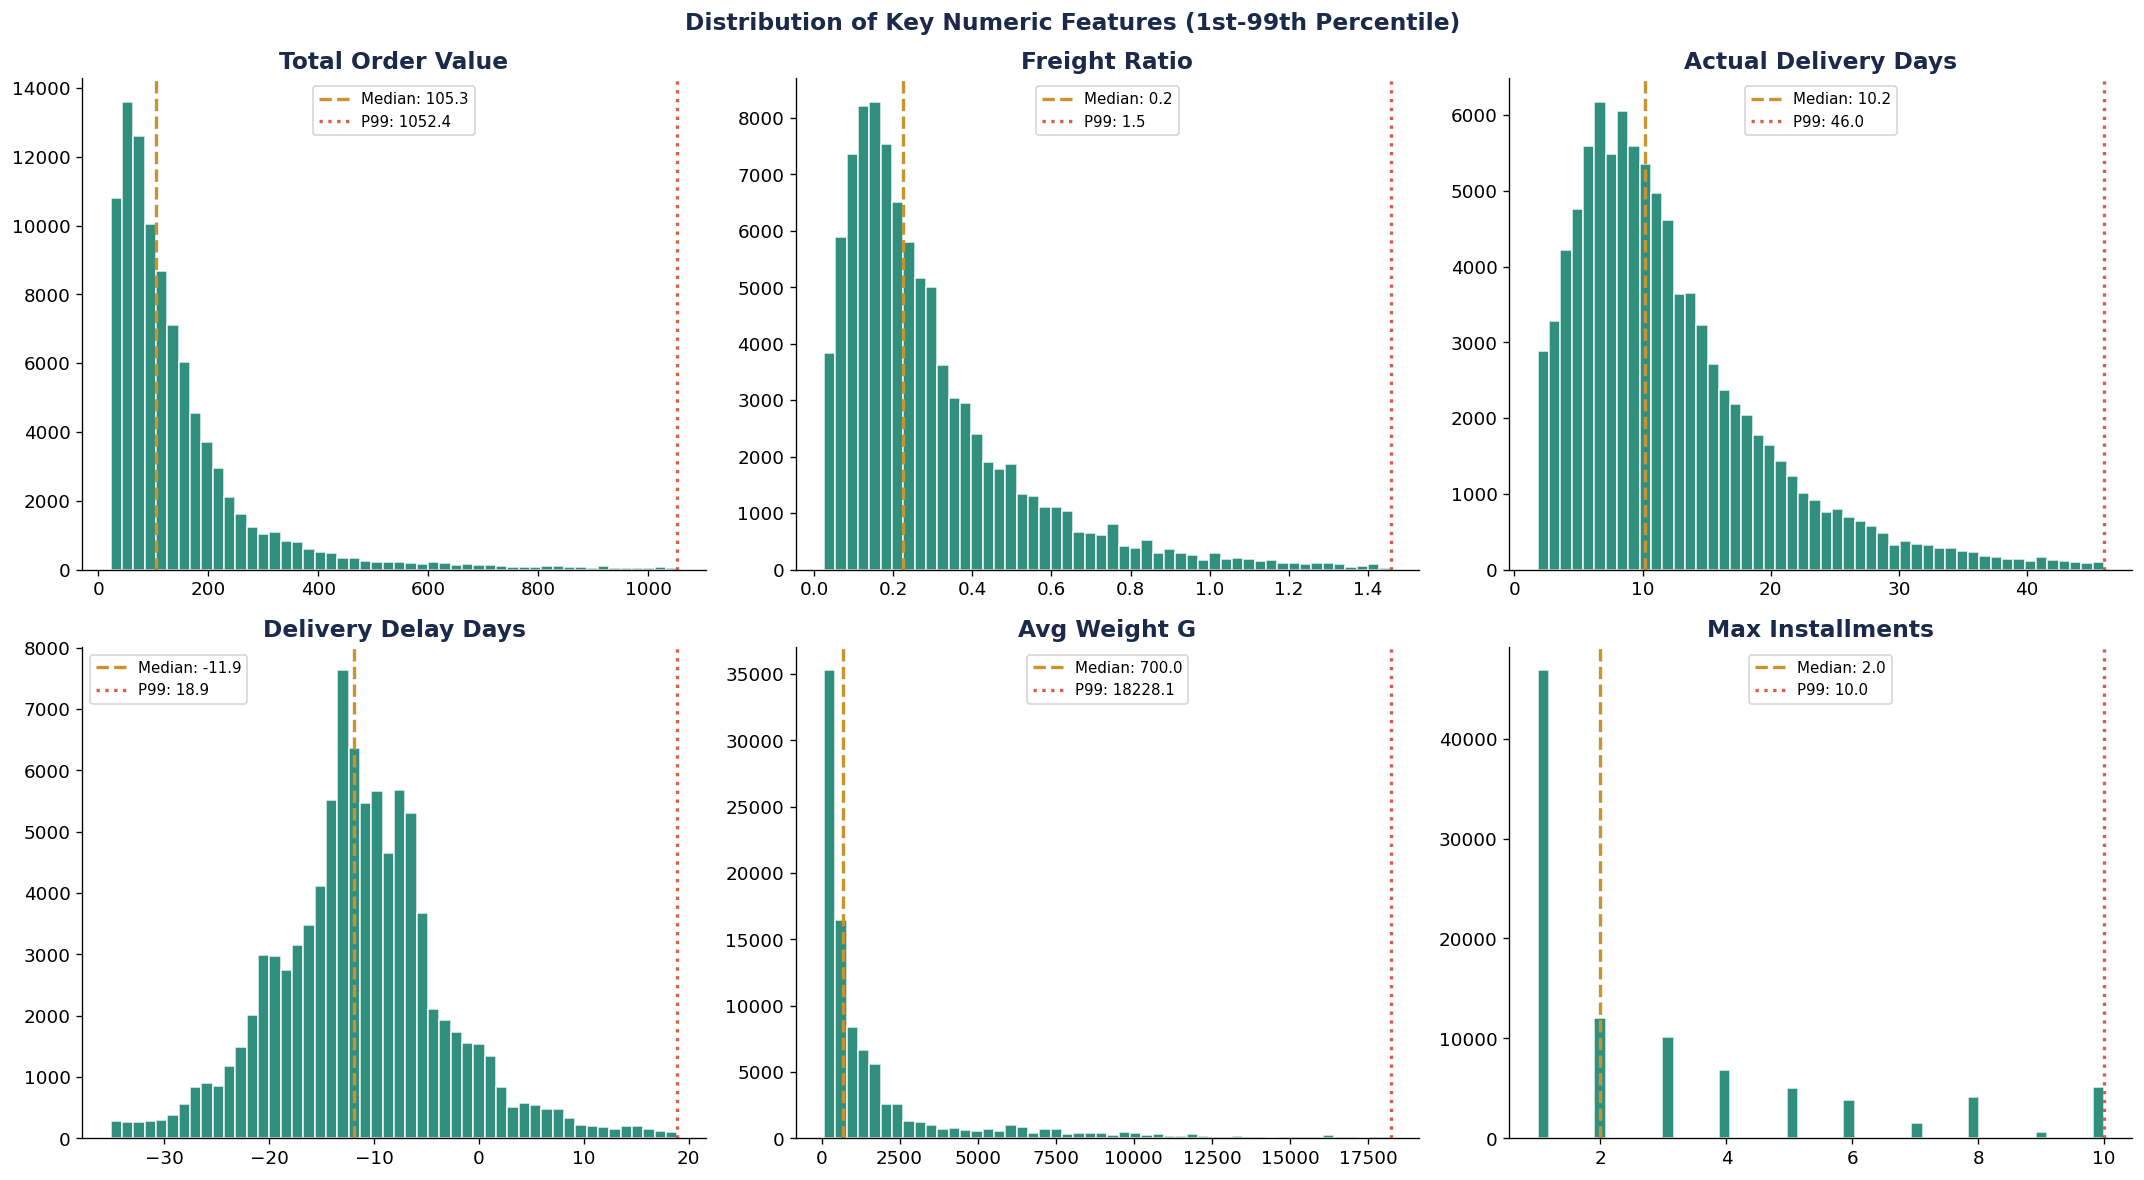

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(outlier_cols):
    ax = axes[i]
    s = master[col].dropna()
    lo = s.quantile(0.01)
    hi = s.quantile(0.99)
    s_clip = s[(s >= lo) & (s <= hi)]

    ax.hist(s_clip, bins=50, color=TEAL, edgecolor='white', alpha=0.85)
    ax.axvline(s.median(), color=GOLD, linewidth=2, linestyle='--',
               label=f'Median: {s.median():.1f}')
    ax.axvline(s.quantile(0.99), color=CORAL, linewidth=2, linestyle=':',
               label=f'P99: {s.quantile(0.99):.1f}')
    ax.set_title(col.replace('_', ' ').title(), color=NAVY, fontweight='bold')
    ax.legend(fontsize=9)

for j in range(len(outlier_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Key Numeric Features (1st-99th Percentile)',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 6: Cross-Feature Interactions</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Do combinations of features predict bad experience better than each alone?</p>
</div>

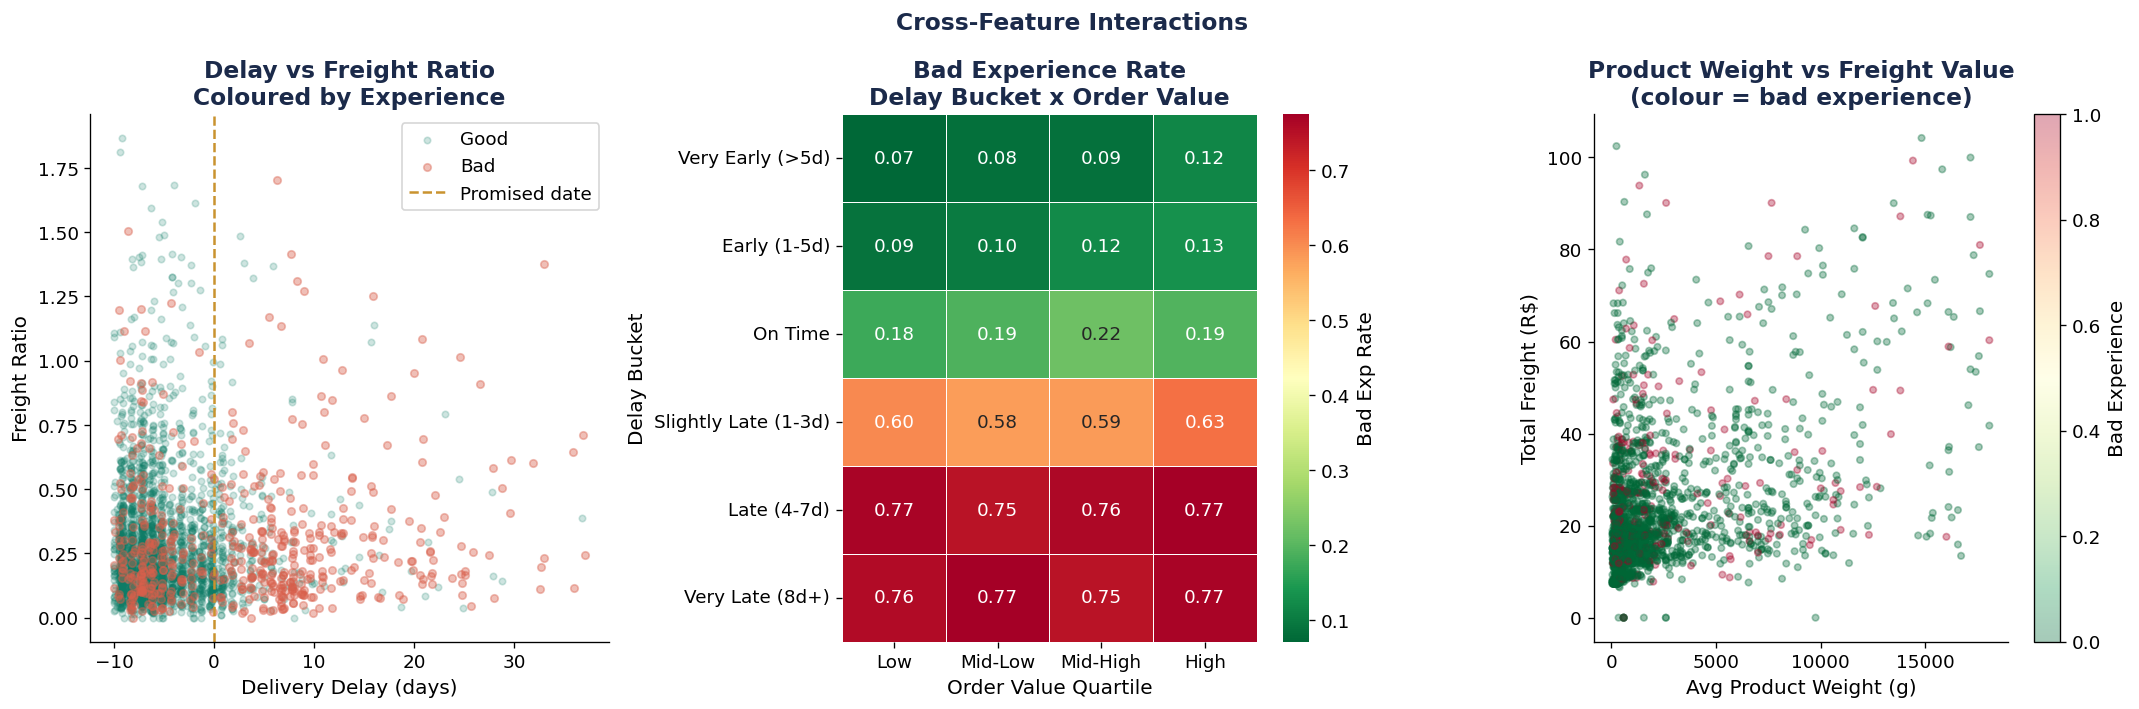

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Delay vs freight_ratio scatter coloured by target
ax = axes[0]
if 'delivery_delay_days' in master.columns and 'freight_ratio' in master.columns:
    s = master.dropna(subset=['delivery_delay_days', 'freight_ratio']).copy()
    s = s[(s['delivery_delay_days'].between(-10, 40)) & (s['freight_ratio'].between(0, 2))]
    s = s.sample(min(3000, len(s)), random_state=42)
    good_s = s[s['bad_experience'] == 0]
    bad_s  = s[s['bad_experience'] == 1]
    ax.scatter(good_s['delivery_delay_days'], good_s['freight_ratio'],
               alpha=0.2, s=15, color=TEAL, label='Good')
    ax.scatter(bad_s['delivery_delay_days'], bad_s['freight_ratio'],
               alpha=0.4, s=20, color=CORAL, label='Bad')
    ax.axvline(0, color=GOLD, linewidth=1.5, linestyle='--', label='Promised date')
    ax.legend()
ax.set_title('Delay vs Freight Ratio\nColoured by Experience', color=NAVY, fontweight='bold')
ax.set_xlabel('Delivery Delay (days)')
ax.set_ylabel('Freight Ratio')

# Plot 2: Heatmap — delay bucket x order value bin
ax = axes[1]
pivot_data = master.dropna(subset=['order_value_bin', 'delay_bucket'])
if len(pivot_data) > 0:
    hm = pivot_data.groupby(
        ['delay_bucket', 'order_value_bin'], observed=True
    )['bad_experience'].mean().unstack()
    if hm.shape[0] > 0 and hm.shape[1] > 0:
        sns.heatmap(hm, ax=ax, cmap='RdYlGn_r', annot=True, fmt='.2f',
                    linewidths=0.5, cbar_kws={'label': 'Bad Exp Rate'})
        ax.set_title('Bad Experience Rate\nDelay Bucket x Order Value', color=NAVY, fontweight='bold')
        ax.set_xlabel('Order Value Quartile')
        ax.set_ylabel('Delay Bucket')

# Plot 3: Weight vs freight coloured by bad_experience
ax = axes[2]
if 'avg_weight_g' in master.columns and 'total_freight' in master.columns:
    s2 = master.dropna(subset=['avg_weight_g', 'total_freight']).copy()
    s2 = s2[(s2['avg_weight_g'] < s2['avg_weight_g'].quantile(0.99)) &
             (s2['total_freight'] < s2['total_freight'].quantile(0.99))]
    s2 = s2.sample(min(3000, len(s2)), random_state=42)
    sc = ax.scatter(s2['avg_weight_g'], s2['total_freight'],
                    c=s2['bad_experience'], cmap='RdYlGn_r', alpha=0.35, s=15)
    plt.colorbar(sc, ax=ax, label='Bad Experience')
ax.set_title('Product Weight vs Freight Value\n(colour = bad experience)', color=NAVY, fontweight='bold')
ax.set_xlabel('Avg Product Weight (g)')
ax.set_ylabel('Total Freight (R$)')

plt.suptitle('Cross-Feature Interactions', fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 7: Temporal Patterns</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Does when you order affect the experience you get?</p>
</div>

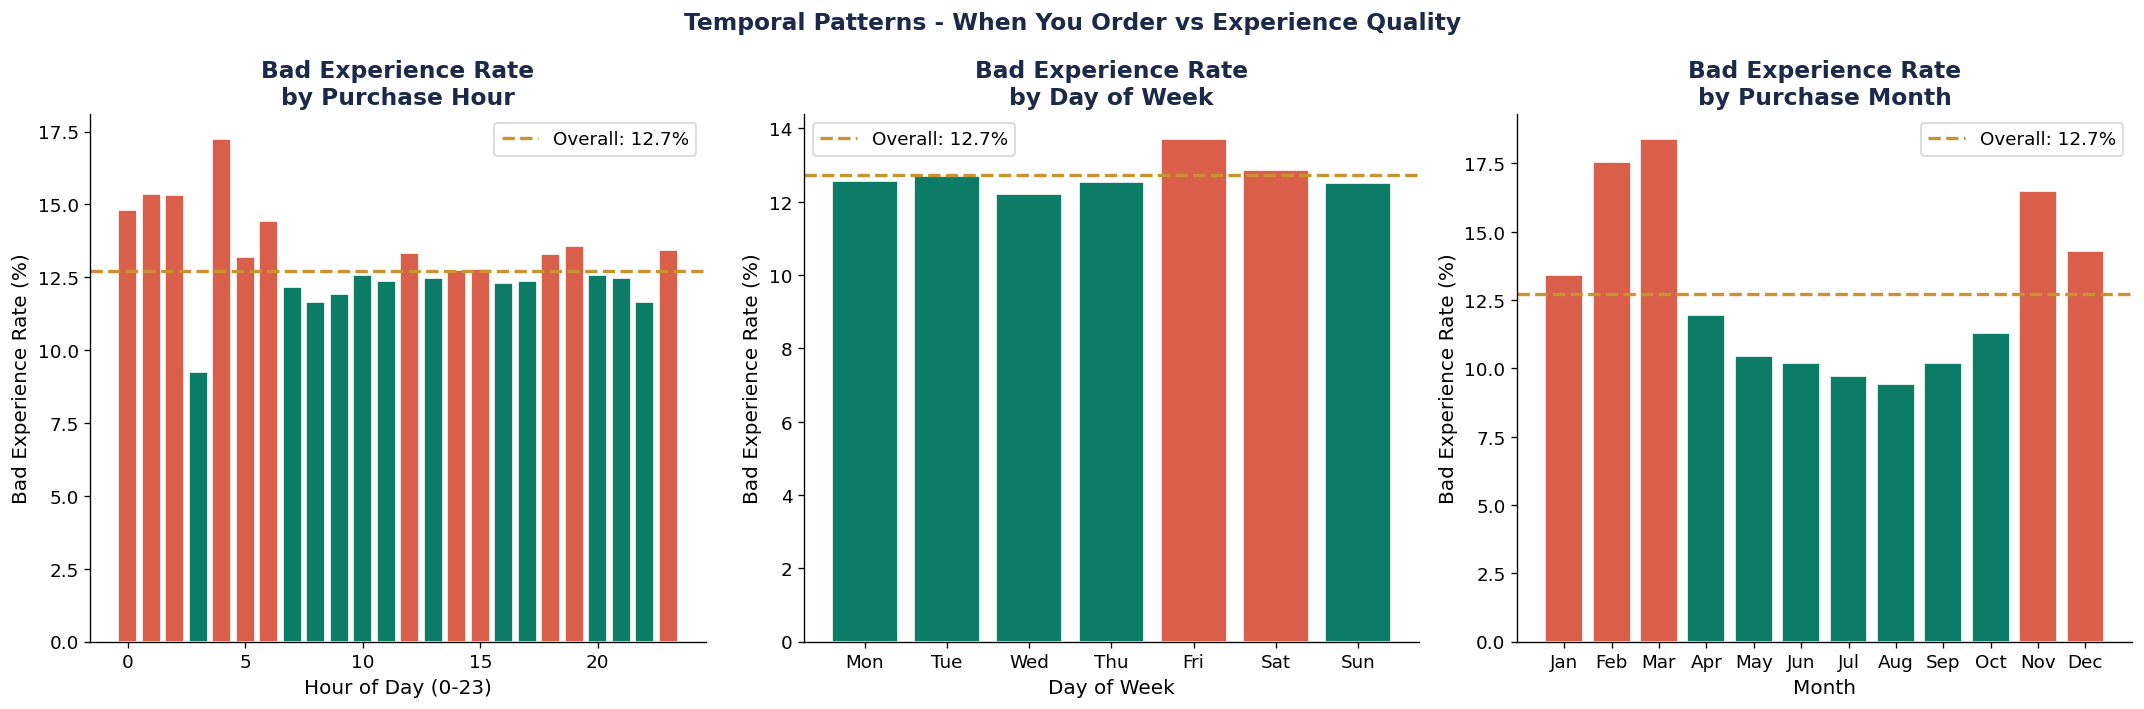

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
overall_pct = master['bad_experience'].mean() * 100

# Plot 1: by hour
if 'purchase_hour' in master.columns:
    hour_stats = master.groupby('purchase_hour')['bad_experience'].mean() * 100
    ax = axes[0]
    colors = [CORAL if v > overall_pct else TEAL for v in hour_stats.values]
    ax.bar(hour_stats.index, hour_stats.values, color=colors, edgecolor='white')
    ax.axhline(overall_pct, color=GOLD, linewidth=2, linestyle='--',
               label=f'Overall: {overall_pct:.1f}%')
    ax.set_title('Bad Experience Rate\nby Purchase Hour', color=NAVY, fontweight='bold')
    ax.set_xlabel('Hour of Day (0-23)')
    ax.set_ylabel('Bad Experience Rate (%)')
    ax.legend()

# Plot 2: by day of week
if 'purchase_dayofweek' in master.columns:
    day_stats = master.groupby('purchase_dayofweek')['bad_experience'].mean() * 100
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    ax = axes[1]
    xlabels = [day_labels[int(d)] for d in day_stats.index if int(d) < 7]
    colors = [CORAL if v > overall_pct else TEAL for v in day_stats.values]
    ax.bar(xlabels, day_stats.values, color=colors, edgecolor='white')
    ax.axhline(overall_pct, color=GOLD, linewidth=2, linestyle='--',
               label=f'Overall: {overall_pct:.1f}%')
    ax.set_title('Bad Experience Rate\nby Day of Week', color=NAVY, fontweight='bold')
    ax.set_xlabel('Day of Week')
    ax.set_ylabel('Bad Experience Rate (%)')
    ax.legend()

# Plot 3: by month
if 'purchase_month' in master.columns:
    month_stats = master.groupby('purchase_month')['bad_experience'].mean() * 100
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    ax = axes[2]
    xlabels = [month_labels[int(m) - 1] for m in month_stats.index if 1 <= int(m) <= 12]
    colors = [CORAL if v > overall_pct else TEAL for v in month_stats.values]
    ax.bar(xlabels, month_stats.values, color=colors, edgecolor='white')
    ax.axhline(overall_pct, color=GOLD, linewidth=2, linestyle='--',
               label=f'Overall: {overall_pct:.1f}%')
    ax.set_title('Bad Experience Rate\nby Purchase Month', color=NAVY, fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel('Bad Experience Rate (%)')
    ax.legend()

plt.suptitle('Temporal Patterns - When You Order vs Experience Quality',
             fontsize=14, color=NAVY, fontweight='bold')
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 8: Correlation Heatmap</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Numeric feature correlation landscape</p>
</div>

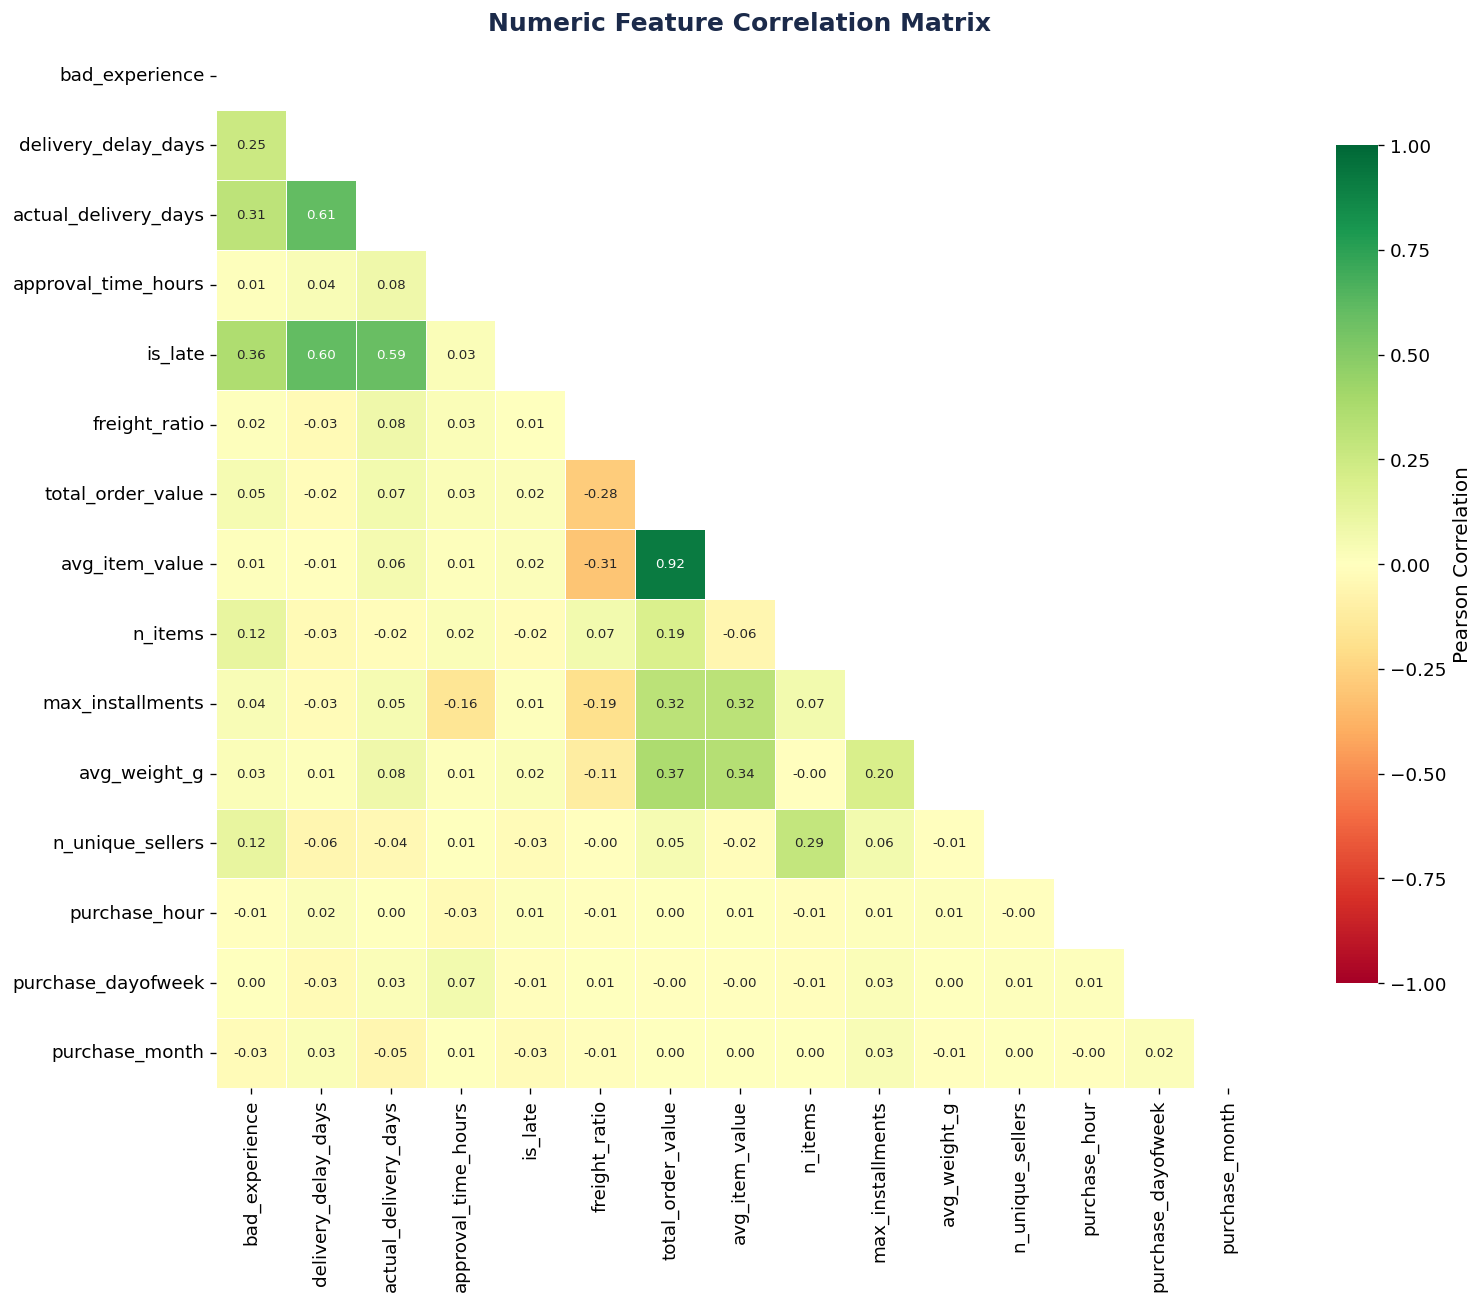

Top correlations with bad_experience:
------------------------------------------
  is_late                      +0.3602  (up)
  actual_delivery_days         +0.3058  (up)
  delivery_delay_days          +0.2525  (up)
  n_items                      +0.1237  (up)
  n_unique_sellers             +0.1185  (up)
  total_order_value            +0.0485  (up)
  max_installments             +0.0354  (up)
  purchase_month               -0.0271  (down)
  avg_weight_g                 +0.0251  (up)
  freight_ratio                +0.0150  (up)
  avg_item_value               +0.0132  (up)
  approval_time_hours          +0.0120  (up)
  purchase_hour                -0.0055  (down)
  purchase_dayofweek           +0.0039  (up)


In [13]:
corr_candidates = ['bad_experience', 'delivery_delay_days', 'actual_delivery_days',
                    'approval_time_hours', 'is_late', 'freight_ratio', 'total_order_value',
                    'avg_item_value', 'n_items', 'max_installments', 'avg_weight_g',
                    'n_unique_sellers', 'purchase_hour', 'purchase_dayofweek', 'purchase_month']

corr_cols = [c for c in corr_candidates if c in master.columns]
corr_matrix = master[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson Correlation'}
)
ax.set_title('Numeric Feature Correlation Matrix', color=NAVY, fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

print("Top correlations with bad_experience:")
print("-" * 42)
target_corr = corr_matrix['bad_experience'].drop('bad_experience').sort_values(
    key=abs, ascending=False)
for feat, corr in target_corr.items():
    direction = 'up' if corr > 0 else 'down'
    print(f"  {feat:<28} {corr:>+.4f}  ({direction})")


<div style="background: linear-gradient(90deg, #1B2A4A, #0D7C66); padding: 14px 24px; border-radius: 8px; margin: 30px 0 12px 0;">
<h2 style="color: white; margin: 0; font-family: Georgia, serif;">Part 9: Feature Scorecard</h2>
<p style="color: #C9932F; margin: 4px 0 0 0; font-size: 1.05em;">Rank all features by their association with bad_experience</p>
</div>

In [14]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = chi2_contingency(ct)
    n = ct.sum().sum()
    k = min(ct.shape) - 1
    v = np.sqrt(chi2 / (n * k)) if k > 0 else 0.0
    return float(v), float(p)

scorecard = []

# Numeric: point-biserial correlation
num_feats = ['delivery_delay_days', 'actual_delivery_days', 'approval_time_hours',
             'is_late', 'freight_ratio', 'total_order_value', 'avg_item_value',
             'n_items', 'max_installments', 'avg_weight_g', 'n_unique_sellers',
             'purchase_hour', 'purchase_dayofweek', 'purchase_month']

for col in num_feats:
    if col not in master.columns:
        continue
    valid = master[[col, 'bad_experience']].dropna()
    if len(valid) < 30:
        continue
    corr, p = pointbiserialr(valid[col], valid['bad_experience'])
    scorecard.append({
        'feature': col, 'type': 'Numeric',
        'association': abs(corr), 'raw_corr': corr, 'p_value': p
    })

# Categorical: Cramer's V
cat_feats = ['payment_type', 'customer_state', 'main_category',
             'delay_bucket', 'order_value_bin']

for col in cat_feats:
    if col not in master.columns:
        continue
    valid = master[[col, 'bad_experience']].dropna()
    if len(valid) < 30:
        continue
    v, p = cramers_v(valid[col].astype(str), valid['bad_experience'].astype(str))
    scorecard.append({
        'feature': col, 'type': 'Categorical',
        'association': v, 'raw_corr': v, 'p_value': p
    })

scorecard_df = (pd.DataFrame(scorecard)
                .sort_values('association', ascending=False)
                .reset_index(drop=True))
scorecard_df['rank'] = scorecard_df.index + 1
scorecard_df['significant'] = scorecard_df['p_value'] < 0.05

print("Feature Scorecard - Ranked by Association Strength with bad_experience")
print("-" * 75)
print(f"{'Rank':<5} {'Feature':<28} {'Type':<12} {'Strength':>10} {'Significant':>12}")
print("-" * 75)
for _, row in scorecard_df.iterrows():
    sig = 'Yes' if row['significant'] else 'No'
    print(f"  {int(row['rank']):<4} {row['feature']:<28} {row['type']:<12}"
          f" {row['association']:>10.4f} {sig:>12}")


Feature Scorecard - Ranked by Association Strength with bad_experience
---------------------------------------------------------------------------
Rank  Feature                      Type           Strength  Significant
---------------------------------------------------------------------------
  1    delay_bucket                 Categorical      0.4184          Yes
  2    is_late                      Numeric          0.3602          Yes
  3    actual_delivery_days         Numeric          0.3058          Yes
  4    delivery_delay_days          Numeric          0.2525          Yes
  5    n_items                      Numeric          0.1237          Yes
  6    n_unique_sellers             Numeric          0.1185          Yes
  7    customer_state               Categorical      0.0846          Yes
  8    main_category                Categorical      0.0709          Yes
  9    order_value_bin              Categorical      0.0592          Yes
  10   total_order_value            Numeric     

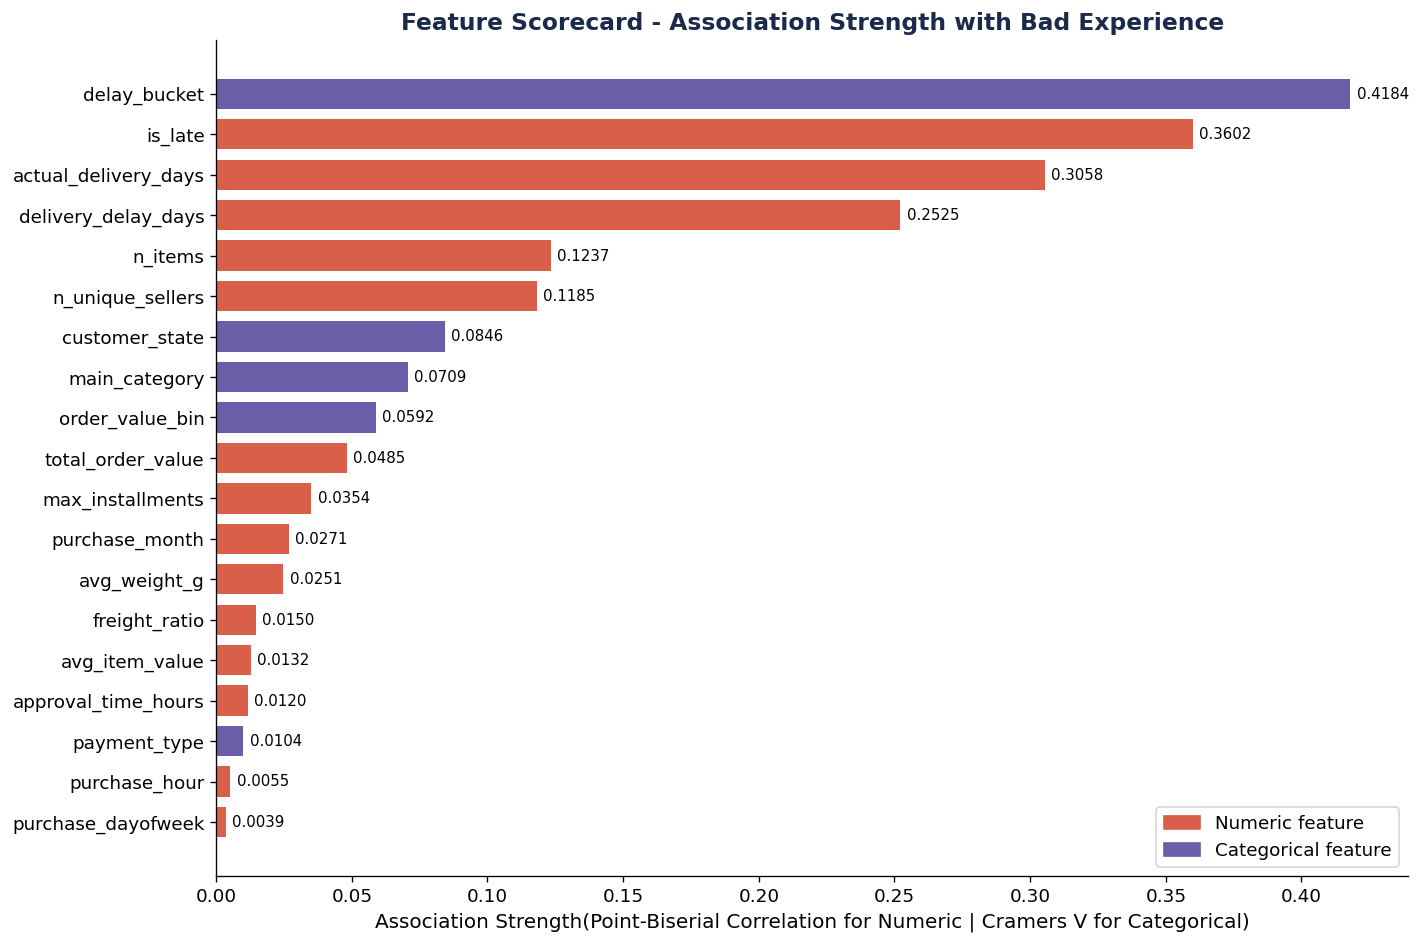

In [15]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = [CORAL if t == 'Numeric' else PURPLE for t in scorecard_df['type']]
bars = ax.barh(
    scorecard_df['feature'][::-1],
    scorecard_df['association'][::-1],
    color=list(reversed(colors)),
    edgecolor='white', linewidth=1.2
)
ax.set_title('Feature Scorecard - Association Strength with Bad Experience',
             color=NAVY, fontweight='bold', fontsize=14)
ax.set_xlabel('Association Strength''(Point-Biserial Correlation for Numeric | Cramers V for Categorical)')

for bar, val in zip(bars, scorecard_df['association'][::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

legend_handles = [
    mpatches.Patch(color=CORAL,  label='Numeric feature'),
    mpatches.Patch(color=PURPLE, label='Categorical feature'),
]
ax.legend(handles=legend_handles)
plt.tight_layout()
plt.show()


<div style="background: linear-gradient(90deg, #E0F4EF, #FDF6E8); border-left: 5px solid #0D7C66; border-right: 5px solid #C9932F; padding: 16px 20px; border-radius: 6px; margin: 20px 0;">
<strong style="color: #1B2A4A;">Notebook 2 Complete - Key Findings</strong>
<ul style="color: #333; font-size: 1.05em; line-height: 1.8; margin-top: 8px;">
<li><strong>delivery_delay_days</strong> and <strong>is_late</strong> are the strongest predictors — late orders are significantly more likely to get a bad review.</li>
<li><strong>actual_delivery_days</strong> also strongly separates good from bad experiences.</li>
<li><strong>freight_ratio</strong> is moderately associated — high freight relative to price correlates with dissatisfaction.</li>
<li>Categorical features like <strong>product category</strong> and <strong>customer state</strong> show variation but weaker overall signal.</li>
<li>Temporal features (hour, day, month) show weak but detectable patterns.</li>
</ul>
</div>

**Next: Notebook 3 - Signal Extraction (Feature Selection, PCA, Dimensionality Reduction)**
